In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

zip_path = "/content/drive/MyDrive/BrainTumorProject/brain-tumor-mri-dataset.zip"

print("File Exists:", os.path.exists(zip_path))

File Exists: True


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/BrainTumorProject/brain-tumor-mri-dataset.zip"

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset Extracted Successfully")

✅ Dataset Extracted Successfully


In [ ]:
import os

print("📂 Dataset Structure:\n")

for root, dirs, files in os.walk("/content/dataset"):
    print(root, "→", len(files))

📂 Dataset Structure:

/content/dataset → 0
/content/dataset/Testing → 0
/content/dataset/Testing/meningioma → 306
/content/dataset/Testing/notumor → 405
/content/dataset/Testing/pituitary → 300
/content/dataset/Testing/glioma → 300
/content/dataset/Training → 0
/content/dataset/Training/meningioma → 1339
/content/dataset/Training/notumor → 1595
/content/dataset/Training/pituitary → 1457
/content/dataset/Training/glioma → 1321


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(
    rescale=1./255
)

print("✅ Preprocessing Ready")

✅ Preprocessing Ready


In [ ]:
train_data = train_gen.flow_from_directory(
    "/content/dataset/Training",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    "/content/dataset/Testing",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


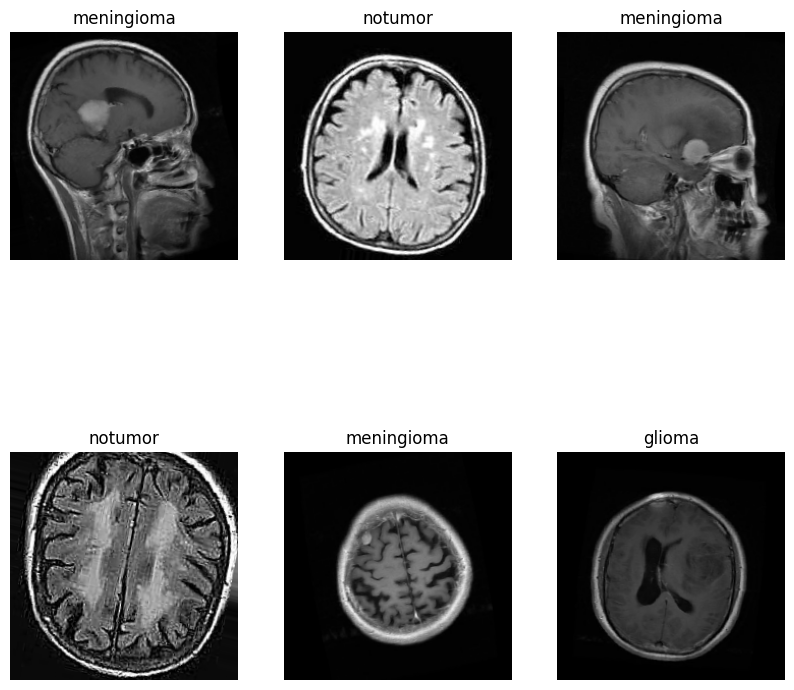

In [ ]:
images, labels = next(train_data)

class_names = list(train_data.class_indices.keys())

plt.figure(figsize=(10,10))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(class_names[labels[i].argmax()])
    plt.axis("off")

plt.show()

In [ ]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        4,
        activation='softmax'
    )

])

print("✅ CNN Model Created")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ CNN Model Created


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,908 (91.20 MB)

 Trainable params: 23,907,908 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model Compiled Successfully")

✅ Model Compiled Successfully


In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 85s 439ms/step - accuracy: 0.6859 - loss: 0.8846 - val_accuracy: 0.7803 - val_loss: 0.5779
Epoch 2/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 73s 406ms/step - accuracy: 0.8286 - loss: 0.4558 - val_accuracy: 0.7368 - val_loss: 0.7508
Epoch 3/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 76s 424ms/step - accuracy: 0.8589 - loss: 0.3691 - val_accuracy: 0.8375 - val_loss: 0.4580
Epoch 4/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 73s 408ms/step - accuracy: 0.8685 - loss: 0.3384 - val_accuracy: 0.8070 - val_loss: 0.4834
Epoch 5/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 73s 408ms/step - accuracy: 0.8855 - loss: 0.2979 - val_accuracy: 0.8566 - val_loss: 0.3934
Epoch 6/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 77s 431ms/step - accuracy: 0.8946 - loss: 0.2794 - val_accuracy: 0.8696 - val_loss: 0.3502
Epoch 7/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 73s 410ms/step - accuracy: 0.9025 - loss: 0.2565 - val_accuracy: 0.8635 - val_loss: 0.3629
Epoch 8/10
179/179 ━━━━━━━━━━━━━━━━━━━━ 73s 406ms/step - accuracy: 0.9116 - loss: 0

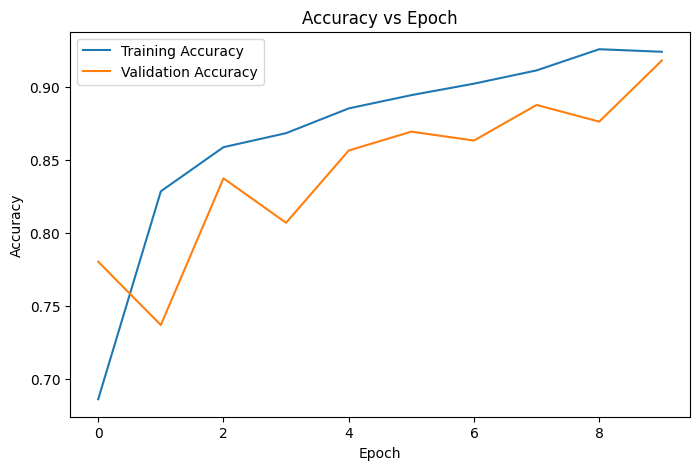

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")

plt.legend()

plt.show()

In [ ]:
loss, accuracy = model.evaluate(test_data)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9184 - loss: 0.2109
Test Loss: 0.21088959276676178
Test Accuracy: 0.9183829426765442


In [ ]:
model.save(
    "/content/drive/MyDrive/BrainTumorProject/models/brain_tumor_cnn.keras"
)

print("✅ Model Saved Successfully")

✅ Model Saved Successfully


In [ ]:
predictions = model.predict(test_data)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

class_names = list(test_data.class_indices.keys())

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step
              precision    recall  f1-score   support

      glioma       0.92      0.88      0.90       300
  meningioma       0.88      0.82      0.85       306
     notumor       0.91      1.00      0.95       405
   pituitary       0.98      0.95      0.97       300

    accuracy                           0.92      1311
   macro avg       0.92      0.91      0.91      1311
weighted avg       0.92      0.92      0.92      1311



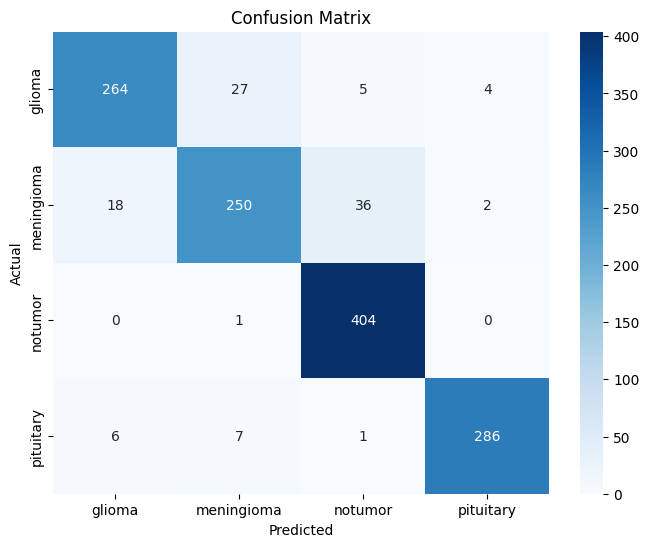

In [ ]:
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

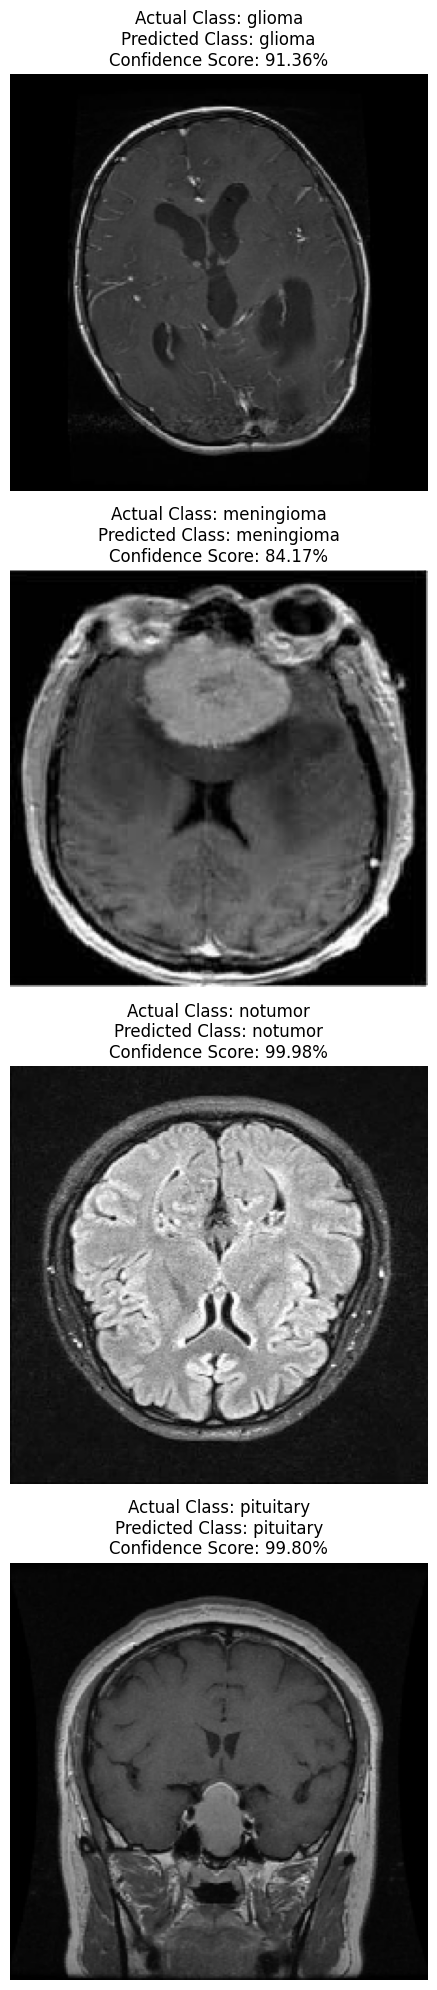

Accuracy on selected images: 100.00%


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# Load model
model = load_model(
    "/content/drive/MyDrive/BrainTumorProject/models/brain_tumor_cnn.keras"
)

classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

test_images = [
    glob.glob("/content/dataset/Testing/glioma/*")[0],
    glob.glob("/content/dataset/Testing/meningioma/*")[0],
    glob.glob("/content/dataset/Testing/notumor/*")[0],
    glob.glob("/content/dataset/Testing/pituitary/*")[0]
]

correct = 0

plt.figure(figsize=(6,20))

for i, img_path in enumerate(test_images):

    actual_class = os.path.basename(
        os.path.dirname(img_path)
    )

    img = image.load_img(
        img_path,
        target_size=(224,224)
    )

    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(
        img_array,
        verbose=0
    )

    predicted_index = np.argmax(prediction)
    predicted_class = classes[predicted_index]

    confidence = prediction[0][predicted_index] * 100

    if predicted_class == actual_class:
        correct += 1

    # One image per row
    plt.subplot(4,1,i+1)

    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Actual Class: {actual_class}\n"
        f"Predicted Class: {predicted_class}\n"
        f"Confidence Score: {confidence:.2f}%"
    )

plt.tight_layout()
plt.show()

accuracy = correct / len(test_images) * 100

print(f"Accuracy on selected images: {accuracy:.2f}%")

In [ ]:
!pip install gradio

In [3]:
import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Load trained model
model = load_model(
    "/content/drive/MyDrive/BrainTumorProject/models/brain_tumor_cnn.keras"
)

classes = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

def predict_tumor(img):

    # Resize image
    img = img.resize((224, 224))

    # Convert image to array
    img_array = image.img_to_array(img)

    # Normalize
    img_array = img_array / 255.0

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array, verbose=0)

    # Return probabilities directly
    scores = {
        classes[i]: float(prediction[0][i])
        for i in range(len(classes))
    }

    return scores

demo = gr.Interface(
    fn=predict_tumor,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=4),
    title="Brain Tumor Classification",
    description="Upload an MRI image to predict the tumor type."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0a136096675e750998.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
